# 04 · Which funnel stage to invest in? — mediation (pathmc)

**The business decision.** We have a fixed budget to split across the growth funnel —
**onboarding → engagement → activation → conversion** — and want to put it where it moves paid
conversion the most. The complication is that the stages form a **chain**: money spent improving
onboarding doesn't only help onboarding, it *cascades* downstream into engagement, activation, and
ultimately conversion. So we can't just correlate each stage with revenue; we have to trace the causal
*paths* and decide where a push travels furthest.

### The concept: mediation, direct and indirect effects

When a treatment $X$ affects an outcome $Y$ *through* an intermediate variable $M$ (a **mediator**), the
total effect splits in two:

- the **direct effect** — $X$'s influence on $Y$ that does *not* go through $M$ (Pearl's *natural direct
  effect*, NDE);
- the **indirect effect** — the part that flows $X \to M \to Y$ (the *natural indirect effect*, NIE).

Total effect = direct + indirect, and the **proportion mediated** = indirect / total tells you how much
of a stage's value is really realised *downstream*. In a linear model the indirect effect is just the
**product of the coefficients along the path** (the classic "a·b" of mediation analysis) — `pathmc`
gives us exactly this via `effect(path)`, which returns the **posterior product-of-coefficients along the
path** (exact for a linear SCM — not a Monte-Carlo simulation through the graph), so we get every path's effect
*with uncertainty*.

### The catch this notebook is honest about

Mediation leans on a **stronger** assumption than a simple treatment-effect analysis: no unmeasured
confounding of the *mediator–outcome* link (on top of the usual treatment–outcome one). If some
unmeasured trait drives both engagement *and* conversion, the direct/indirect *split* is biased even when
the *total* effect is fine. So Step 6 doesn't just report the split — it **stress-tests how much such
confounding would have to exist to flip the "invest here" decision.**

> **On real data.** Swap in your **product-analytics event data** — per-user onboarding score, engagement,
> activation flag, conversion — which every growth team already logs. The method needs the funnel's causal
> *order* to be known (it usually is) and the no-hidden-mediator-confounder assumption to be defensible
> (Step 6 shows how to argue it).

`pathmc` builds the chain as a structural causal model and computes **path-specific effects** as the posterior
**product-of-coefficients along each path** — exact for a linear SCM (we reserve "simulate through the
intervened graph" for `do()`/`ate()`) — the modern, uncertainty-aware mediation
analysis.

It follows the repo's fixed **7-step contract**: question → simulate → identify → estimate → validate → decide in € → caveats.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import pathmc
from cmp import dgp, plots, estimators as est
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
FIT = dict(draws=400, tune=400, chains=2) if FAST else dict(draws=1500, tune=1500, chains=4)
SEED = 13

## 2 · Simulate a ground truth

We simulate the funnel as a **causal chain**: `onboarding_score → engagement → activated → converted`,
with `channel_quality` feeding both engagement and activation (a common driver we'll need to account for).
Each arrow is a real structural equation with a planted coefficient, so we know the **true** total effect
of onboarding on conversion *and how it splits across paths* — which is exactly what we'll ask the model
to recover. By construction most of onboarding's effect flows the long way round (`engagement → activated →
converted`), with a smaller slice going `engagement → converted` directly. If the method can rediscover
that split from data alone, we can trust it on a funnel where we *don't* know the answer.


In [2]:
df, true_effects = dgp.funnel(n=1000, seed=SEED)
print("TRUE effects of onboarding on conversion:")
for k, v in true_effects.items(): print(f"  {k:36s} {v:.2f}")
df.head()

TRUE effects of onboarding on conversion:
  indirect_via_engagement_activated    3.17
  indirect_via_engagement_only         0.77
  total                                3.94


,onboarding_score,channel_quality,engagement,activated,converted
0,0.864798,0.726815,2.576471,3.869429,4.870321
1,0.855303,0.790067,3.206651,5.673260,6.371102
2,0.811023,0.348493,2.493785,4.691864,5.394113
3,0.261446,0.465793,0.572682,1.261547,1.264003
4,0.077199,0.887974,1.520775,3.259916,3.146544


## 3 · Identify — direct vs indirect effects (NDE / NIE)

For a chain $X\to M\to Y$ the **total effect** decomposes into a **natural direct effect** and
**natural indirect effect** (Pearl):

$$\text{TE}=\text{NDE}+\text{NIE},\quad
\text{NDE}=\mathbb E[Y(1,M(0))-Y(0,M(0))],\quad
\text{NIE}=\mathbb E[Y(1,M(1))-Y(1,M(0))].$$

Under a linear SCM these are the **product-of-coefficients**: indirect $=a\cdot b$, direct $=c$, and
`pathmc` computes each path-specific effect as exactly that product along the path (exact for the linear
SCM here — not a Monte-Carlo simulation through the graph). The **proportion mediated** $=\text{NIE}/\text{TE}$
tells you how much of onboarding's value is "really" downstream engagement/activation. Crucially we
**include a direct onboarding→converted edge in the model and test it**, so a near-100%-mediated answer is
*discovered* (the coefficient comes out ≈ 0), not forced by leaving the edge out.

**Assumptions (stronger than a single-link analysis):** no unmeasured confounding of $X\!-\!Y$,
$M\!-\!Y$, *and* $X\!-\!M$, plus **no treatment-induced mediator–outcome confounding** — no $M\!-\!Y$ confounder is
itself affected by $X$ (the practical stand-in for the genuine *cross-world independence* assumption of Pearl/Imai). Natural effects are *not identified* if that last one fails — and the
$M\!-\!Y$ confounding assumption is the one most likely to break, so we stress-test it in step 6.

## 4 · Estimate — fit the chain and query every path

We hand `pathmc` the **whole chain at once** — one equation per stage — rather than three disconnected
regressions. That matters: because the model knows the full graph, it can propagate an intervention on
onboarding *through* engagement and activation to conversion, giving genuine path-specific effects instead
of naive stage-by-stage correlations. The `effects_summary()` below lists every structural coefficient
(the $a$'s and $b$'s from Step 3); Step 5 then combines them into total, direct, and indirect effects with
uncertainty.

Throughout, uncertainty is reported as a **credible interval** — the Bayesian analogue of a confidence interval, the range that contains the parameter with the stated posterior probability; note the `effects_summary()` table below shows a **94% HDI** (`hdi_3%`/`hdi_97%`) while Step 5's print reports a **90%** interval.


In [3]:
# We INCLUDE a direct onboarding_score -> converted edge (c_on) even though we suspect there
# isn't one, so the 'how much is mediated?' answer is DISCOVERED (c_on's posterior ~ 0) rather
# than assumed by omitting the edge.
spec = '''
engagement ~ e_on*onboarding_score + e_ch*channel_quality
activated  ~ a_eng*engagement + a_ch*channel_quality
converted  ~ c_act*activated + c_eng*engagement + c_on*onboarding_score
'''
m = pathmc.model(spec, data=df)
idata = m.fit(random_seed=SEED, progressbar=False, **FIT)
print(f"mediation model convergence: {est.convergence_report(idata)["summary"]}")
m.effects_summary().round(3)


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta_converted, sigma_engagement, beta_engagement, sigma_activated, beta_activated, sigma_converted]


Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 7 seconds.


mediation model convergence: max r-hat 1.000 - min ESS 3737 - divergences 0


,mean,sd,hdi_3%,hdi_97%
name,,,,
e_on,2.153,0.045,2.074,2.241
e_ch,1.132,0.044,1.053,1.222
a_eng,1.617,0.018,1.585,1.652
a_ch,0.592,0.051,0.491,0.681
c_act,0.901,0.022,0.858,0.941
c_eng,0.336,0.045,0.251,0.420
c_on,0.060,0.055,-0.044,0.162


**Real-data check + the naive-regression trap.** Before trusting the split: (a) do the funnel graph's own testable implications survive on this data, and (b) what would a *naive* controlled regression — onboarding **plus** the mediators, all in one OLS — report for onboarding? The path queries above need neither trick; the naive regression, as the numbers show, misreads onboarding's total effect.

In [4]:
# (a) Falsify the funnel DAG against the data: does the graph survive its own implied independences?
# At alpha=0.05 each test still rejects ~5% of the time even when the graph is CORRECT, so the number of
# violations ~ Binomial(n_tests, 0.05). We read the count against that false-positive budget -- a lone
# marginal rejection among several tests is expected noise, not evidence against the graph (approximate:
# it assumes the tests are independent) -- rather than treating any single violation as fatal.
from scipy.stats import binom
imp = m.test_implications(alpha=0.05)
p_chance = float(binom.sf(imp.n_violations - 1, imp.n_tests, 0.05))   # P(>= this many rejections by chance)
verdict = 'graph survives falsification' if p_chance > 0.05 else 'graph is contradicted by the data'
print(f"Testable implications of the funnel DAG: {imp.n_tests} checked -> {imp.n_violations} violated; "
      f"P(>={imp.n_violations} by chance at alpha=0.05) = {p_chance:.2f} ({verdict}).")
for _, t in imp.results[imp.results.significant].iterrows():   # name the flagged test, don't leave it a mystery
    print(f"  the flagged independence: {t.x} ⊥ {t.y} | {{{t.conditioning_set}}}  "
          f"(partial corr {t.partial_corr:+.3f}, p = {t.p_value:.3f}) — in this simulation every implied "
          f"independence holds by construction, so this is a knowable false positive, exactly what the "
          f"Binomial budget above prices in.")

# (b) The naive-regression trap: regress converted on onboarding AND the mediators together in one OLS.
Xn = np.column_stack([np.ones(len(df)), df['onboarding_score'].values,
                      df['engagement'].values, df['activated'].values])
beta_naive = np.linalg.lstsq(Xn, df['converted'].values, rcond=None)[0]
on_coef = beta_naive[1]
print(f"Naive OLS  converted ~ onboarding + engagement + activated : onboarding coef = {on_coef:+.3f}  "
      f"(vs TRUE total {true_effects['total']:.2f}).")
print(f"Putting the mediators in the regression collapses onboarding's coefficient toward ~0 (it now reads only the "
      f"leftover DIRECT effect, not the total). That is exactly why a naive controlled regression MISreads "
      f"onboarding's real leverage -- and why the path decomposition above, not OLS, is what you need.")

Testable implications of the funnel DAG: 3 checked -> 1 violated; P(>=1 by chance at alpha=0.05) = 0.14 (graph survives falsification).
  the flagged independence: channel_quality ⊥ onboarding_score | {}  (partial corr +0.087, p = 0.006) — in this simulation every implied independence holds by construction, so this is a knowable false positive, exactly what the Binomial budget above prices in.
Naive OLS  converted ~ onboarding + engagement + activated : onboarding coef = +0.059  (vs TRUE total 3.94).
Putting the mediators in the regression collapses onboarding's coefficient toward ~0 (it now reads only the leftover DIRECT effect, not the total). That is exactly why a naive controlled regression MISreads onboarding's real leverage -- and why the path decomposition above, not OLS, is what you need.


## 5 · Validate — recover the total, the paths, the DIRECT effect, and the proportion mediated

We query four things and check each against the planted truth: the **total** effect of onboarding on
conversion; the effect flowing through each **path**; the **direct** (natural direct) effect — which the
model is now free to find, and which should come out **≈ 0** if onboarding really works only through the
funnel; and the **proportion mediated** (indirect ÷ total). A proportion near 100% *with a direct effect
whose interval includes 0* is the honest version of "onboarding works almost entirely by feeding the rest
of the funnel" — a very different investment story from a direct effect.

In [5]:
def get_draws(res):
    d = res.draws
    return np.asarray(d() if callable(d) else d)

total_d = get_draws(m.ate("converted", "onboarding_score"))
direct_d = get_draws(m.effect("onboarding_score -> converted"))          # NDE (should be ~ 0)
via_act = get_draws(m.effect("onboarding_score -> engagement -> activated -> converted"))
via_eng = get_draws(m.effect("onboarding_score -> engagement -> converted"))
indirect_d = via_act + via_eng
prop_mediated = indirect_d / total_d

def line(lbl, d, truth):
    print(f"{lbl:38s} {d.mean():5.2f}  (true {truth:.2f})  [90% {np.quantile(d,.05):.2f}, {np.quantile(d,.95):.2f}]")
line("TOTAL onboarding -> converted", total_d, true_effects['total'])
line("  DIRECT (NDE) onboarding -> converted", direct_d, 0.0)
line("  via engagement->activated->conv", via_act, true_effects['indirect_via_engagement_activated'])
line("  via engagement->converted", via_eng, true_effects['indirect_via_engagement_only'])
print(f"The DIRECT effect's 90% interval includes 0, so the ~{prop_mediated.mean():.0%} proportion mediated is "
      f"DISCOVERED — the model was free to find a direct onboarding->conversion path and the data say there isn't one.")

TOTAL onboarding -> converted           3.92  (true 3.94)  [90% 3.77, 4.08]
  DIRECT (NDE) onboarding -> converted  0.06  (true 0.00)  [90% -0.03, 0.15]
  via engagement->activated->conv       3.14  (true 3.17)  [90% 2.96, 3.31]
  via engagement->converted             0.72  (true 0.77)  [90% 0.56, 0.89]
The DIRECT effect's 90% interval includes 0, so the ~98% proportion mediated is DISCOVERED — the model was free to find a direct onboarding->conversion path and the data say there isn't one.


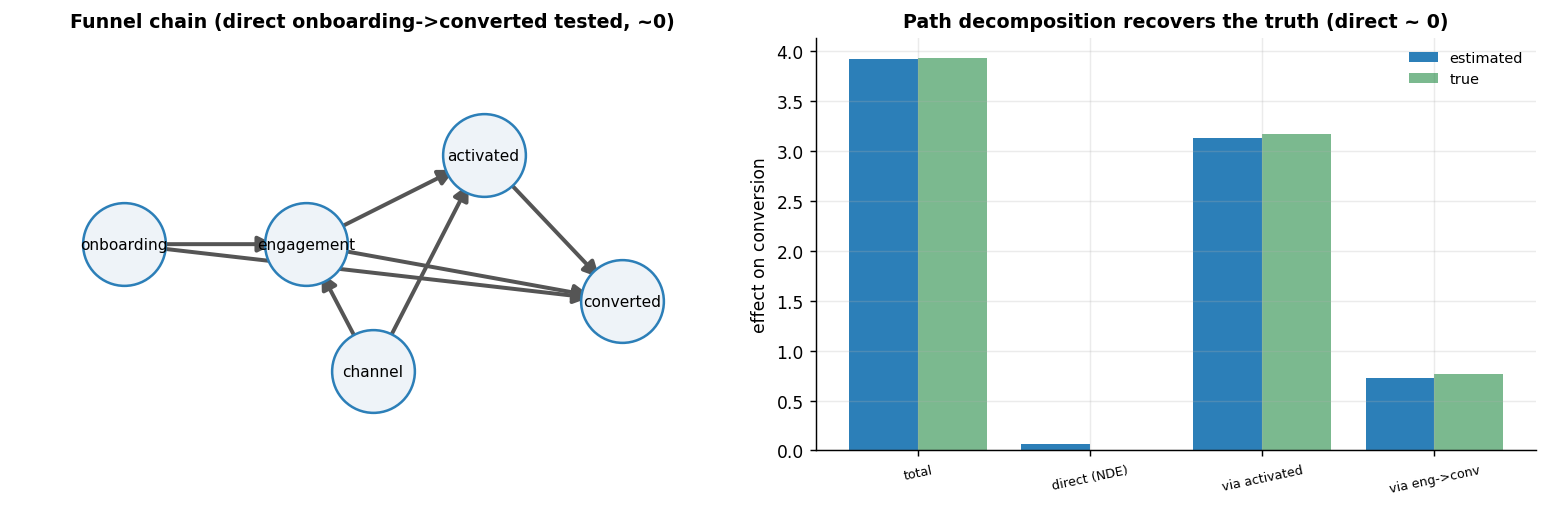

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
pos = {"onboarding": (0.05,0.5), "engagement": (0.38,0.5), "activated": (0.7,0.78), "converted": (0.95,0.32), "channel": (0.5,0.1)}
edges = [("onboarding","engagement"),("engagement","activated"),("activated","converted"),
         ("engagement","converted"),("onboarding","converted"),   # onboarding->converted is TESTED (comes out ~0)
         ("channel","engagement"),("channel","activated")]
plots.draw_dag(ax[0], pos, edges, title="Funnel chain (direct onboarding->converted tested, ~0)")
labels = ["total","direct (NDE)","via activated","via eng->conv"]
means = [total_d.mean(), direct_d.mean(), via_act.mean(), via_eng.mean()]
truths = [true_effects['total'], 0.0, true_effects['indirect_via_engagement_activated'], true_effects['indirect_via_engagement_only']]
x = np.arange(len(labels))
ax[1].bar(x-0.2, means, 0.4, color=plots.BLUE, label="estimated")
ax[1].bar(x+0.2, truths, 0.4, color=plots.GREEN, alpha=0.6, label="true")
ax[1].set_xticks(x); ax[1].set_xticklabels(labels, fontsize=7, rotation=12); ax[1].legend(frameon=False, fontsize=8)
ax[1].set_ylabel("effect on conversion"); ax[1].set_title("Path decomposition recovers the truth (direct ~ 0)")
fig.tight_layout()

**How to read this.** *Left* is the causal graph we fit — including a **direct** onboarding→conversion
arrow, which we deliberately added so the model could find a direct effect if one existed. *Right* — the
estimated total and each path effect (blue) sit on top of the planted truths (green), and the **direct (NDE)
bar is ≈ 0** (its interval includes zero): onboarding works almost entirely *through* the funnel, and that
near-100%-mediated result is now **discovered, not assumed**. This is the decomposition a naive "regress
conversion on each stage" analysis cannot give you.

## 6 · Decide, in euros — a *rankable* leverage metric, and its fragility

Two moves, and both correct a trap.

**(1) Rank the levers — but not by "€ per one-unit change."** A one-unit move means something completely
different per stage (one unit of `onboarding_score` is a large fraction of its whole range; one unit of
`activated` is a fraction of a standard deviation), so a €/unit ranking is not a rankable quantity — it
*reverses* when you switch to comparable **per-standard-deviation** moves. The decision-relevant metric is
**ROI = (€ value of a 1-SD lift) ÷ (€ cost to produce that 1-SD lift)**; we state an illustrative equal cost
per SD and report `P(ROI > 1)`. Swap in your real per-stage costs and the ranking follows.

**(2) Stress-test the split — coherently.** The direct/indirect decomposition rests on *no unmeasured
confounding of the mediator–outcome link* (Step 3). A confounder of engagement→conversion biases the fitted
edge — but that same edge carries **both** the engagement lever **and** onboarding's total effect, so an
honest sweep must shrink them *together* (a common mistake is to bias one and freeze the other). We do that
per posterior draw and read off how much of the engagement→conversion edge a hidden confounder would have to
explain before the leverage ranking changes.

     lever  €/unit  €/SD  ROI (€/€)  P(ROI>1)
engagement     215   176       1.76       1.0
 activated     108   159       1.59       1.0
onboarding     470   133       1.33       1.0

Per-UNIT vs per-SD DISAGREE: a 1-unit onboarding move is only 0.28 SD (tiny) while a
1-unit activated move is 1.47 SD (large), so €/unit is not rankable — use ROI on a stated
cost. At equal €100/SD the order is engagement > activated > onboarding and all clear break-even.
Fragility: engagement's per-SD lead over activation vanishes once a hidden M-Y confounder explains ~53% of the engagement->converted edge — a real caveat. Onboarding (the root cause) stays robust.


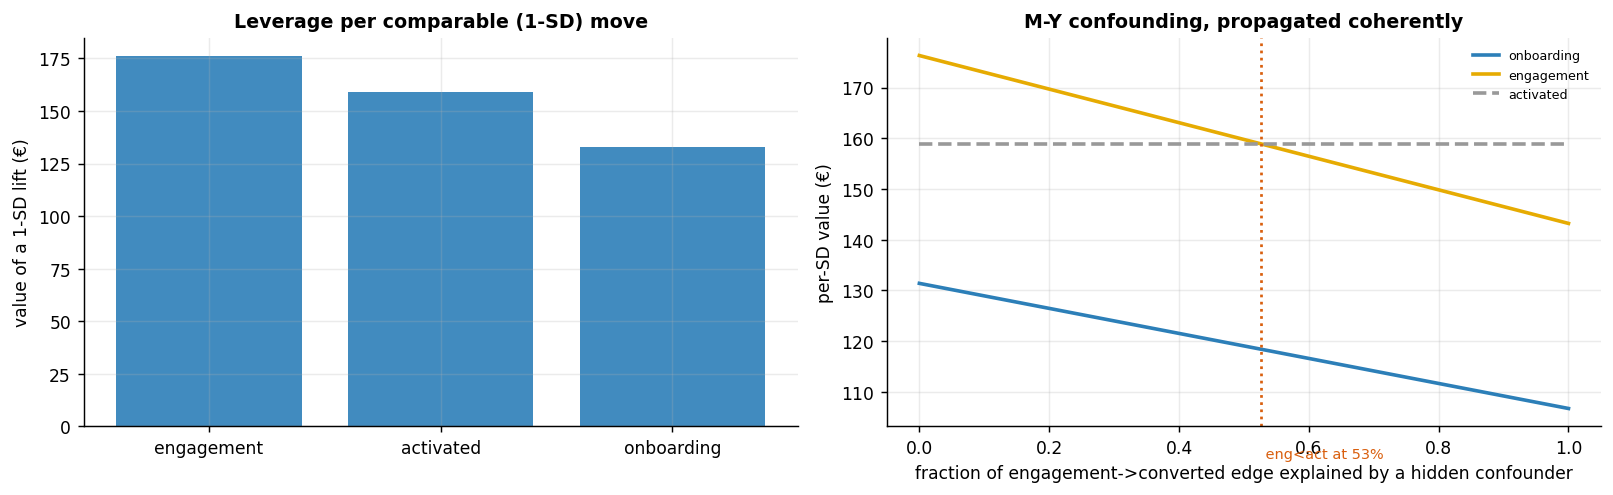

In [7]:
VALUE = 120.0
sd = {"onboarding": df.onboarding_score.std(), "engagement": df.engagement.std(), "activated": df.activated.std()}
eff = {"onboarding": total_d,
       "engagement": get_draws(m.ate("converted", "engagement")),
       "activated":  get_draws(m.ate("converted", "activated"))}

# Three views of leverage — "€ per one-unit change" is unit-dependent and reverses under comparable units.
per_unit = {k: v.mean() * VALUE for k, v in eff.items()}                 # 1) €/unit  (units differ per stage!)
per_sd   = {k: v.mean() * sd[k] * VALUE for k, v in eff.items()}         # 2) €/SD    (comparable magnitudes)
COST_SD  = 100.0                                                         # € to move any stage by 1 SD (STATED, illustrative)
roi      = {k: (eff[k] * sd[k] * VALUE) / COST_SD for k in eff}          # 3) ROI = value of a 1-SD lift / its cost
tbl = pd.DataFrame({
    "lever": list(eff),
    "€/unit": [round(per_unit[k]) for k in eff],
    "€/SD": [round(per_sd[k]) for k in eff],
    "ROI (€/€)": [round(roi[k].mean(), 2) for k in eff],
    "P(ROI>1)": [round((roi[k] > 1).mean(), 2) for k in eff],
}).sort_values("€/SD", ascending=False)

# Coherent M-Y sensitivity: a hidden confounder of engagement->converted inflates the fitted c_eng; the
# TRUE value is c_eng - b. BOTH the engagement lever AND onboarding-total flow through that edge, so we
# shrink them together per posterior draw (the old sweep froze onboarding - incoherent).
c_eng = idata.posterior["beta_converted"].sel(converted_predictors="engagement").values.ravel()
c_act = idata.posterior["beta_converted"].sel(converted_predictors="activated").values.ravel()
a_eng = idata.posterior["beta_activated"].sel(activated_predictors="engagement").values.ravel()
e_on  = idata.posterior["beta_engagement"].sel(engagement_predictors="onboarding_score").values.ravel()
edge  = abs(c_eng.mean()); bias = np.linspace(0, edge, 20)               # remove 0..100% of the fitted edge
onb_v = np.array([(e_on * (a_eng * c_act + (c_eng - b))).mean() * sd["onboarding"] * VALUE for b in bias])
eng_v = np.array([((c_eng - b) + a_eng * c_act).mean() * sd["engagement"] * VALUE for b in bias])
act_v = np.full_like(bias, c_act.mean() * sd["activated"] * VALUE)
flip  = bias[np.argmax(eng_v < act_v)] / edge if np.any(eng_v < act_v) else np.nan

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.9))
ax[0].bar(tbl["lever"], tbl["€/SD"], color=plots.BLUE, alpha=0.9)
ax[0].set_ylabel("value of a 1-SD lift (€)"); ax[0].set_title("Leverage per comparable (1-SD) move")
ax[1].plot(bias/edge, onb_v, color=plots.BLUE, lw=2, label="onboarding")
ax[1].plot(bias/edge, eng_v, color=plots.GOLD, lw=2, label="engagement")
ax[1].plot(bias/edge, act_v, color=plots.GREY, lw=2, ls="--", label="activated")
if not np.isnan(flip):
    ax[1].axvline(flip, color=plots.ORANGE, ls=":"); ax[1].text(flip, eng_v.max()*0.55, f" eng<act at {flip:.0%}", fontsize=8, color=plots.ORANGE)
ax[1].set_xlabel("fraction of engagement->converted edge explained by a hidden confounder")
ax[1].set_ylabel("per-SD value (€)"); ax[1].set_title("M-Y confounding, propagated coherently"); ax[1].legend(frameon=False, fontsize=7)
fig.tight_layout()
print(tbl.to_string(index=False))
print(f"\nPer-UNIT vs per-SD DISAGREE: a 1-unit onboarding move is only {sd['onboarding']:.2f} SD (tiny) while a\n"
      f"1-unit activated move is {sd['activated']:.2f} SD (large), so €/unit is not rankable — use ROI on a stated\n"
      f"cost. At equal €{COST_SD:.0f}/SD the order is {' > '.join(tbl['lever'])} and all clear break-even.")
if not np.isnan(flip):
    print(f"Fragility: engagement's per-SD lead over activation vanishes once a hidden M-Y confounder explains "
          f"~{flip:.0%} of the engagement->converted edge — a real caveat. Onboarding (the root cause) stays robust.")
else:
    print("Engagement's per-SD lead survives even fully explaining away the engagement->converted edge.")

## 7 · Caveats

- **Natural effects lean on strong assumptions** — no unmeasured confounding of any of the three
  links plus the cross-world condition. Step 6 quantified *coherently* (shrinking both affected
  levers together) how much $M\!-\!Y$ confounding would flip the leverage ranking; the point
  estimate alone hides that the engagement-vs-activation ordering is the fragile one.
- **A €/unit leverage ranking is not a rankable quantity** when the stage metrics live on different
  scales — it reverses under per-SD units. Decide on **ROI against a stated cost-to-move**, not €/unit.
- **Don't control away the mechanism.** The goal is to *decompose* the path; adjusting for a
  mediator when you wanted the total effect removes the very thing you're pricing (nb 05).
- **Linear-SCM decomposition is exact only if the SCM is linear.** For strong nonlinearities lean
  on `pathmc`'s numbers, not hand-multiplied coefficients.